In [96]:
# Interpretable Machine Learning for 30-Day Diabetes Hospital Readmission Prediction

#Dataset:** UCI Diabetes 130-US Hospitals for Years 1999–2008  
#Goal:** Predict whether a diabetic inpatient encounter results in readmission within 30 days.


#This project compares multiple machine learning models, evaluates performance using healthcare-relevant metrics, analyzes model interpretability, and checks fairness across demographic groups.

SyntaxError: invalid character '–' (U+2013) (1032499274.py, line 3)

In [ ]:
INSTALL_PACKAGES = True

if INSTALL_PACKAGES:
    import sys
    import subprocess

    packages = [
        "ucimlrepo",
        "scikit-learn",
        "pandas",
        "numpy",
        "matplotlib",
        "seaborn",
        "joblib"
    ]

    for pkg in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

    optional_packages = ["xgboost", "shap"]

    for pkg in optional_packages:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        except Exception as e:
            print(f"Optional package {pkg} could not be installed: {e}")

In [ ]:
import os
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports complete.")

In [ ]:
FAST_MODE = False
RUN_TUNING = False
RUN_OPTIONAL_XGBOOST = True
RUN_OPTIONAL_SHAP = False

print("FAST_MODE:", FAST_MODE)
print("RUN_TUNING:", RUN_TUNING)
print("RUN_OPTIONAL_XGBOOST:", RUN_OPTIONAL_XGBOOST)
print("RUN_OPTIONAL_SHAP:", RUN_OPTIONAL_SHAP)

In [ ]:
LOCAL_CSV_PATH = "diabetic_data.csv"

def load_diabetes_data():
    try:
        from ucimlrepo import fetch_ucirepo

        dataset = fetch_ucirepo(id=296)

        X = dataset.data.features.copy()
        y = dataset.data.targets.copy()

        # Add ID columns if ucimlrepo stores them separately
        if hasattr(dataset.data, "ids") and dataset.data.ids is not None:
            ids = dataset.data.ids.copy()
            X = pd.concat([ids, X], axis=1)

        if isinstance(y, pd.DataFrame):
            y_col = y.columns[0]
            y = y[y_col]

        df = X.copy()
        df["readmitted"] = y.values

        print("Loaded dataset from ucimlrepo.")
        return df

    except Exception as e:
        print("Could not load from ucimlrepo.")
        print("Error:", e)

        if Path(LOCAL_CSV_PATH).exists():
            print(f"Loading local file: {LOCAL_CSV_PATH}")
            return pd.read_csv(LOCAL_CSV_PATH)

        raise FileNotFoundError(
            "Dataset not found. Place diabetic_data.csv in the notebook folder "
            "or enable internet access for ucimlrepo."
        )

In [ ]:
df_raw = load_diabetes_data()

print("Dataset shape:", df_raw.shape)
df_raw.head()

In [ ]:
df = df_raw.copy()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.value_counts())

In [ ]:
print("Readmission outcome counts:")
display(df["readmitted"].value_counts(dropna=False))

print("Readmission outcome proportions:")
display(df["readmitted"].value_counts(normalize=True, dropna=False).round(4))

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="readmitted", order=["NO", ">30", "<30"])
plt.title("Original Readmission Outcome Distribution")
plt.xlabel("Readmission Outcome")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

In [ ]:
df_missing = df.replace("?", np.nan)

missing_rate = df_missing.isna().mean().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_rate": missing_rate,
    "missing_count": df_missing.isna().sum()
})

display(missing_summary.head(25))

In [ ]:
plt.figure(figsize=(10, 6))
missing_rate.head(25).sort_values().plot(kind="barh")
plt.title("Top Missing-Value Rates by Column")
plt.xlabel("Missing Rate")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [ ]:
df = df_raw.copy().replace("?", np.nan)

df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print("Binary target counts:")
display(df["readmitted_30"].value_counts())

print("Binary target proportions:")
display(df["readmitted_30"].value_counts(normalize=True).round(4))

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="readmitted_30")
plt.title("Binary Target Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Encounters")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.show()

In [ ]:
REMOVE_EXPIRED_HOSPICE = True

EXPIRED_HOSPICE_DISPOSITION_IDS = {11, 13, 14, 19, 20, 21}

MEDICATION_COLUMNS = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

In [ ]:
def map_icd9_to_group(code):
    if pd.isna(code):
        return "Missing"

    code = str(code).strip()

    if code == "":
        return "Missing"

    if code.startswith("V"):
        return "Supplementary_V"

    if code.startswith("E"):
        return "Supplementary_E"

    try:
        value = float(code)
    except ValueError:
        return "Other"

    if 390 <= value <= 459 or value == 785:
        return "Circulatory"
    elif 460 <= value <= 519 or value == 786:
        return "Respiratory"
    elif 520 <= value <= 579 or value == 787:
        return "Digestive"
    elif 250 <= value < 251:
        return "Diabetes"
    elif 800 <= value <= 999:
        return "Injury"
    elif 710 <= value <= 739:
        return "Musculoskeletal"
    elif 580 <= value <= 629 or value == 788:
        return "Genitourinary"
    elif 140 <= value <= 239:
        return "Neoplasms"
    elif 240 <= value <= 279:
        return "Endocrine_Except_Diabetes"
    elif 680 <= value <= 709 or value == 782:
        return "Skin"
    elif 780 <= value <= 799:
        return "Symptoms"
    else:
        return "Other"

In [ ]:
def engineer_features(df_in):
    df = df_in.copy()
    df = df.replace("?", np.nan)

    if "gender" in df.columns:
        df["gender"] = df["gender"].replace({"Unknown/Invalid": np.nan})

    if REMOVE_EXPIRED_HOSPICE and "discharge_disposition_id" in df.columns:
        discharge_numeric = pd.to_numeric(
            df["discharge_disposition_id"],
            errors="coerce"
        )

        before = len(df)

        df = df.loc[
            ~discharge_numeric.isin(EXPIRED_HOSPICE_DISPOSITION_IDS)
        ].copy()

        after = len(df)

        print(f"Removed {before - after} expired/hospice discharge encounters.")

    df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

    for col in ["diag_1", "diag_2", "diag_3"]:
        if col in df.columns:
            df[f"{col}_group"] = df[col].apply(map_icd9_to_group)

    med_cols_present = [
        col for col in MEDICATION_COLUMNS
        if col in df.columns
    ]

    if med_cols_present:
        df["num_med_up"] = (df[med_cols_present] == "Up").sum(axis=1)
        df["num_med_down"] = (df[med_cols_present] == "Down").sum(axis=1)
        df["num_med_steady"] = (df[med_cols_present] == "Steady").sum(axis=1)
        df["num_med_no"] = (df[med_cols_present] == "No").sum(axis=1)

        df["any_med_change_detail"] = (
            (df["num_med_up"] + df["num_med_down"]) > 0
        ).astype(int)

    return df

In [ ]:
df_model = engineer_features(df_raw)

print("Modeling dataset shape:", df_model.shape)

display(df_model[[
    "readmitted",
    "readmitted_30",
    "diag_1",
    "diag_1_group",
    "diag_2",
    "diag_2_group",
    "diag_3",
    "diag_3_group"
]].head())

In [ ]:
TARGET = "readmitted_30"
GROUP_COL = "patient_nbr"

DROP_COLUMNS = [
    "readmitted",
    "readmitted_30",
    "encounter_id",
    "patient_nbr"
]

y_all = df_model[TARGET].astype(int)
groups = df_model[GROUP_COL]

gss_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_val_idx, test_idx = next(
    gss_1.split(df_model, y_all, groups=groups)
)

train_val = df_model.iloc[train_val_idx].copy()
test = df_model.iloc[test_idx].copy()

In [ ]:
gss_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    gss_2.split(
        train_val,
        train_val[TARGET],
        groups=train_val[GROUP_COL]
    )
)

train = train_val.iloc[train_idx].copy()
val = train_val.iloc[val_idx].copy()

In [ ]:
if FAST_MODE:
    train = train.sample(
        min(len(train), 25000),
        random_state=RANDOM_STATE
    )

    val = val.sample(
        min(len(val), 8000),
        random_state=RANDOM_STATE
    )

    test = test.sample(
        min(len(test), 8000),
        random_state=RANDOM_STATE
    )

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

print("\nTrain positive rate:", train[TARGET].mean())
print("Validation positive rate:", val[TARGET].mean())
print("Test positive rate:", test[TARGET].mean())

In [ ]:
X_train = train.drop(
    columns=[col for col in DROP_COLUMNS if col in train.columns]
)

y_train = train[TARGET].astype(int)

X_val = val.drop(
    columns=[col for col in DROP_COLUMNS if col in val.columns]
)

y_val = val[TARGET].astype(int)

X_test = test.drop(
    columns=[col for col in DROP_COLUMNS if col in test.columns]
)

y_test = test[TARGET].astype(int)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

In [ ]:
def target_summary(split_name, y):
    return pd.Series({
        "split": split_name,
        "n": len(y),
        "positive_n": int(y.sum()),
        "positive_rate": float(y.mean())
    })

split_summary = pd.DataFrame([
    target_summary("train", y_train),
    target_summary("validation", y_val),
    target_summary("test", y_test)
])

display(split_summary)

In [ ]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32", "bool"]
).columns.tolist()

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

In [ ]:
def make_ohe():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", make_ohe())
])

In [97]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created.")

Preprocessor created.


In [98]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (
            scores - scores.min()
        ) / (
            scores.max() - scores.min() + 1e-12
        )

    return model.predict(X)

In [99]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    if (tn + fp) == 0:
        return np.nan

    return tn / (tn + fp)

In [100]:
def evaluate_predictions(y_true, y_score, threshold=0.50):
    y_pred = (y_score >= threshold).astype(int)

    metrics = OrderedDict()

    metrics["threshold"] = threshold
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
    metrics["specificity"] = specificity_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    except ValueError:
        metrics["roc_auc"] = np.nan

    try:
        metrics["average_precision"] = average_precision_score(
            y_true,
            y_score
        )
    except ValueError:
        metrics["average_precision"] = np.nan

    return metrics

In [101]:
def find_best_threshold(y_true, y_score, metric="f1", min_precision=None):
    thresholds = np.linspace(0.01, 0.99, 99)

    rows = []

    for threshold in thresholds:
        metrics = evaluate_predictions(
            y_true,
            y_score,
            threshold=threshold
        )

        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    if min_precision is not None:
        eligible = threshold_df[
            threshold_df["precision"] >= min_precision
        ]

        if len(eligible) > 0:
            threshold_df = eligible

    best_idx = threshold_df[metric].idxmax()

    best_threshold = float(
        threshold_df.loc[best_idx, "threshold"]
    )

    return best_threshold, threshold_df
    

In [102]:
def plot_confusion(y_true, y_score, threshold, title):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    display = ConfusionMatrixDisplay(
        cm,
        display_labels=["Not <30", "<30"]
    )

    display.plot(values_format="d", cmap="Blues")

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [103]:
def plot_roc_pr_curves(results_dict, split_name="Validation"):
    plt.figure(figsize=(7, 5))

    for model_name, result in results_dict.items():
        fpr, tpr, _ = roc_curve(
            result["y_true"],
            result["y_score"]
        )

        model_auc = roc_auc_score(
            result["y_true"],
            result["y_score"]
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{model_name} AUC={model_auc:.3f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title(f"ROC Curves on {split_name} Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))

    for model_name, result in results_dict.items():
        precision, recall, _ = precision_recall_curve(
            result["y_true"],
            result["y_score"]
        )

        ap = average_precision_score(
            result["y_true"],
            result["y_score"]
        )

        plt.plot(
            recall,
            precision,
            label=f"{model_name} AP={ap:.3f}"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curves on {split_name} Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [104]:
models = OrderedDict()

In [105]:
models["Dummy prior baseline"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(
        strategy="prior",
        random_state=RANDOM_STATE
    ))
])

In [106]:
models["Logistic Regression balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="saga",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [107]:
models["Random Forest balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=600,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [108]:
models["Extra Trees balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [109]:
models["MLP tabular neural network"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        alpha=1e-5,
        batch_size=512,
        learning_rate_init=5e-4,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

In [110]:
if RUN_OPTIONAL_XGBOOST:
    try:
        from xgboost import XGBClassifier

        negative_count, positive_count = np.bincount(y_train)

        scale_pos_weight = negative_count / max(positive_count, 1)

        models["XGBoost weighted"] = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", XGBClassifier(
                n_estimators=1000,
                max_depth=5,
                learning_rate=0.02,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

        print("XGBoost model added.")

    except Exception as e:
        print("XGBoost unavailable. Skipping.")
        print(e)

print("Models ready:")
list(models.keys())

XGBoost model added.
Models ready:


['Dummy prior baseline',
 'Logistic Regression balanced',
 'Random Forest balanced',
 'Extra Trees balanced',
 'MLP tabular neural network',
 'XGBoost weighted']

In [111]:
trained_models = OrderedDict()
val_results = OrderedDict()
val_metric_rows = []
threshold_tables = {}

In [112]:
for model_name, model in models.items():
    print("\n" + "=" * 80)
    print("Training:", model_name)

    fitted_model = clone(model)

    fitted_model.fit(X_train, y_train)

    y_val_score = get_scores(fitted_model, X_val)

    best_threshold, threshold_table = find_best_threshold(
        y_val,
        y_val_score,
        metric="f1"
    )

    metrics = evaluate_predictions(
        y_val,
        y_val_score,
        threshold=best_threshold
    )

    metrics["model"] = model_name

    trained_models[model_name] = fitted_model

    val_results[model_name] = {
        "y_true": y_val,
        "y_score": y_val_score,
        "threshold": best_threshold
    }

    val_metric_rows.append(metrics)
    threshold_tables[model_name] = threshold_table

    print("Best validation threshold:", round(best_threshold, 3))
    metrics_display = pd.Series(metrics).drop("model")
    metrics_display = pd.to_numeric(metrics_display, errors="coerce")
    display(metrics_display.round(4))


Training: Dummy prior baseline
Best validation threshold: 0.01


threshold            0.0100
accuracy             0.1185
balanced_accuracy    0.5000
precision            0.1185
recall               1.0000
specificity          0.0000
f1                   0.2119
roc_auc              0.5000
average_precision    0.1185
dtype: float64


Training: Logistic Regression balanced
Best validation threshold: 0.51


threshold            0.5100
accuracy             0.6678
balanced_accuracy    0.6011
precision            0.1814
recall               0.5137
specificity          0.6885
f1                   0.2682
roc_auc              0.6347
average_precision    0.1965
dtype: float64


Training: Random Forest balanced
Best validation threshold: 0.42


...

threshold            0.4300
accuracy             0.5675
balanced_accuracy    0.5944
precision            0.1611
recall               0.6297
specificity          0.5591
f1                   0.2566
roc_auc              0.6248
average_precision    0.1736
dtype: float64


Training: MLP tabular neural network
Best validation threshold: 0.06


threshold            0.0600
accuracy             0.7016
balanced_accuracy    0.5970
precision            0.1887
recall               0.4599
specificity          0.7341
f1                   0.2676
roc_auc              0.6306
average_precision    0.1970
dtype: float64


Training: XGBoost weighted
Best validation threshold: 0.52


threshold            0.5200
accuracy             0.7315
balanced_accuracy    0.6076
precision            0.2065
recall               0.4451
specificity          0.7700
f1                   0.2821
roc_auc              0.6537
average_precision    0.2094
dtype: float64

In [113]:
val_metrics = (
    pd.DataFrame(val_metric_rows)
    .set_index("model")
    .sort_values("average_precision", ascending=False)
)

display(val_metrics.round(4))

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
model,,,,,,,,,
XGBoost weighted,0.52,0.7315,0.6076,0.2065,0.4451,0.7700,0.2821,0.6537,0.2094
MLP tabular neural network,0.06,0.7016,0.5970,0.1887,0.4599,0.7341,0.2676,0.6306,0.1970
Logistic Regression balanced,0.51,0.6678,0.6011,0.1814,0.5137,0.6885,0.2682,0.6347,0.1965
Random Forest balanced,0.42,0.6230,0.6141,0.1779,0.6023,0.6258,0.2747,0.6549,0.1938
Extra Trees balanced,0.43,0.5675,0.5944,0.1611,0.6297,0.5591,0.2566,0.6248,0.1736
Dummy prior baseline,0.01,0.1185,0.5000,0.1185,1.0000,0.0000,0.2119,0.5000,0.1185


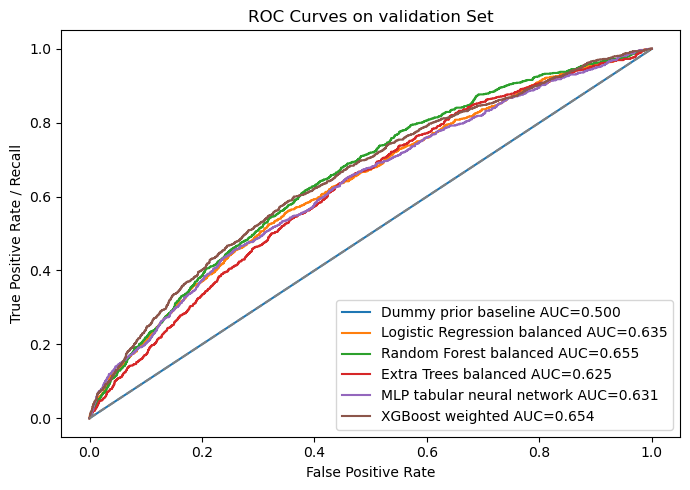

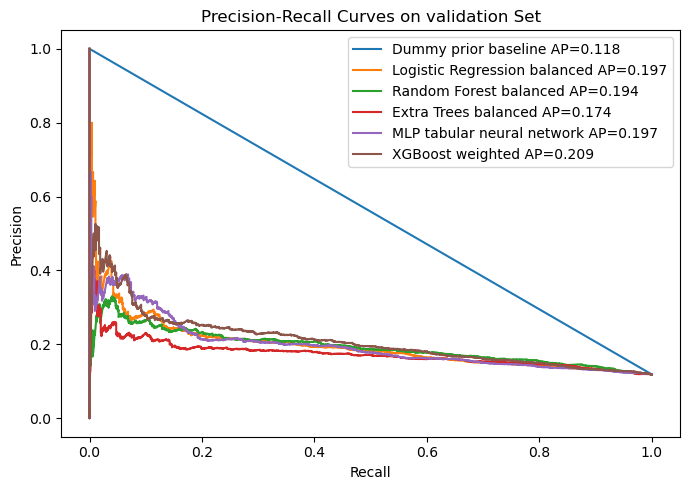

In [114]:
plot_roc_pr_curves(val_results, split_name="validation")

Best validation model by average precision:
XGBoost weighted


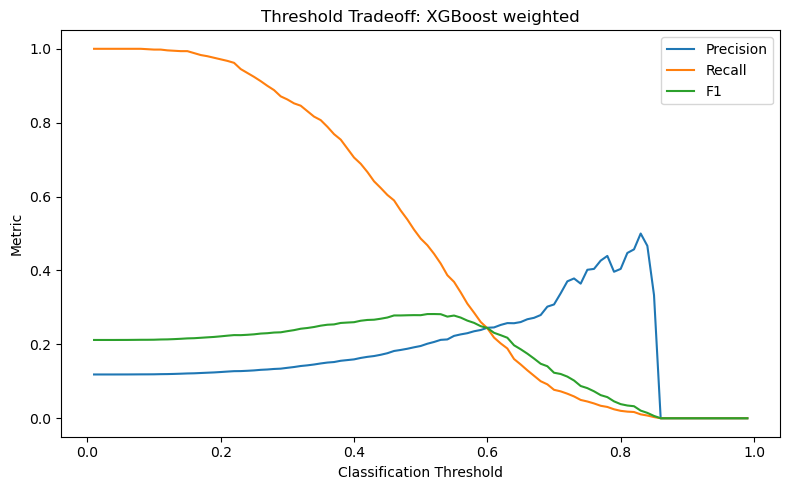

In [115]:
best_val_model_name = val_metrics.index[0]

print("Best validation model by average precision:")
print(best_val_model_name)

threshold_table = threshold_tables[best_val_model_name]

plt.figure(figsize=(8, 5))
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric")
plt.title(f"Threshold Tradeoff: {best_val_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
selection_metric = "average_precision"

best_model_name = val_metrics.sort_values(
    selection_metric,
    ascending=False
).index[0]

best_model = trained_models[best_model_name]
best_threshold = val_results[best_model_name]["threshold"]

print("Selected model:", best_model_name)
print("Validation-tuned threshold:", best_threshold)

Selected model: XGBoost weighted
Validation-tuned threshold: 0.52


In [117]:
test_results = OrderedDict()
test_metric_rows = []

for model_name, fitted_model in trained_models.items():
    y_test_score = get_scores(fitted_model, X_test)

    threshold = val_results[model_name]["threshold"]

    metrics = evaluate_predictions(
        y_test,
        y_test_score,
        threshold=threshold
    )

    metrics["model"] = model_name

    test_metric_rows.append(metrics)

    test_results[model_name] = {
        "y_true": y_test,
        "y_score": y_test_score,
        "threshold": threshold
    }

test_metrics = (
    pd.DataFrame(test_metric_rows)
    .set_index("model")
    .sort_values(selection_metric, ascending=False)
)

display(test_metrics.round(4))

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
model,,,,,,,,,
XGBoost weighted,0.52,0.7158,0.5883,0.1878,0.4213,0.7553,0.2598,0.6396,0.2052
Logistic Regression balanced,0.51,0.6585,0.5910,0.1739,0.5026,0.6794,0.2584,0.6325,0.2046
Random Forest balanced,0.42,0.6046,0.6012,0.1689,0.5966,0.6057,0.2632,0.6444,0.2030
MLP tabular neural network,0.06,0.6891,0.5823,0.1762,0.4424,0.7222,0.2520,0.6254,0.2005
Extra Trees balanced,0.43,0.5516,0.5871,0.1562,0.6336,0.5406,0.2507,0.6215,0.1838
Dummy prior baseline,0.01,0.1184,0.5000,0.1184,1.0000,0.0000,0.2117,0.5000,0.1184


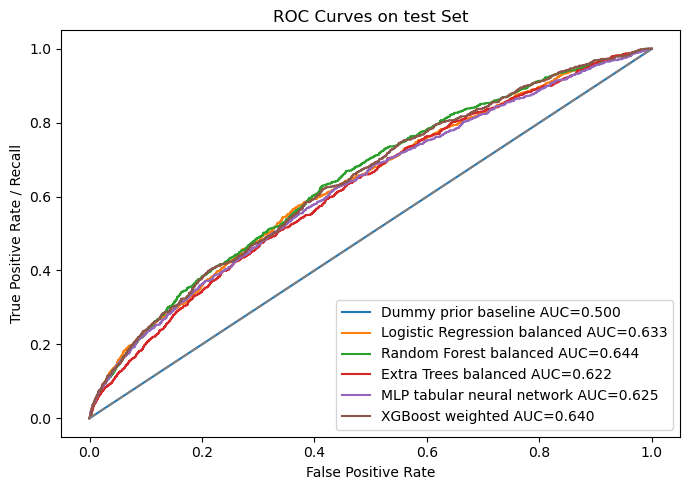

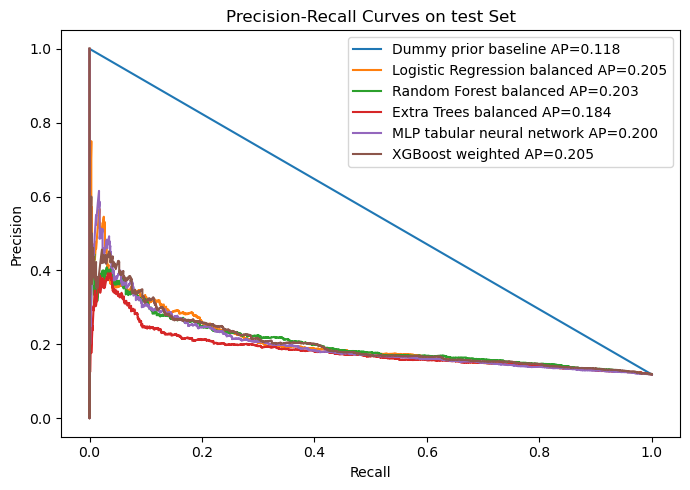

In [118]:
plot_roc_pr_curves(test_results, split_name="test")

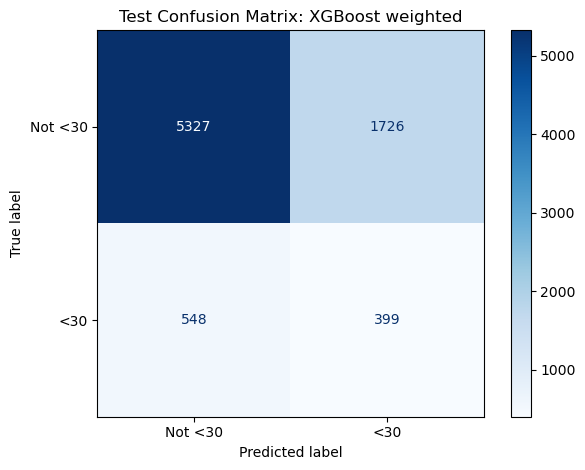

                    precision    recall  f1-score   support

Not readmitted <30     0.9067    0.7553    0.8241      7053
    Readmitted <30     0.1878    0.4213    0.2598       947

          accuracy                         0.7157      8000
         macro avg     0.5472    0.5883    0.5419      8000
      weighted avg     0.8216    0.7157    0.7573      8000



In [119]:
y_test_score_best = test_results[best_model_name]["y_score"]
y_test_pred_best = (y_test_score_best >= best_threshold).astype(int)

plot_confusion(
    y_test,
    y_test_score_best,
    best_threshold,
    f"Test Confusion Matrix: {best_model_name}"
)

print(
    classification_report(
        y_test,
        y_test_pred_best,
        target_names=["Not readmitted <30", "Readmitted <30"],
        digits=4
    )
)

In [120]:
def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    feature_names = []

    feature_names.extend(numeric_features)

    cat_pipeline = preprocessor.named_transformers_["cat"]
    ohe = cat_pipeline.named_steps["onehot"]

    try:
        categorical_names = ohe.get_feature_names_out(categorical_features).tolist()
    except Exception:
        categorical_names = ohe.get_feature_names(categorical_features).tolist()

    feature_names.extend(categorical_names)

    return np.array(feature_names)

In [121]:
logistic_model_names = [
    name for name in trained_models
    if "Logistic Regression" in name
]

if len(logistic_model_names) > 0:
    logistic_name = logistic_model_names[0]
    logistic_model = trained_models[logistic_name]

    feature_names = get_feature_names_from_preprocessor(
        logistic_model.named_steps["preprocess"],
        numeric_features,
        categorical_features
    )

    coefficients = logistic_model.named_steps["model"].coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

    top_positive = coef_df.sort_values(
        "coefficient",
        ascending=False
    ).head(20)

    top_negative = coef_df.sort_values(
        "coefficient",
        ascending=True
    ).head(20)

    print("Top predictors increasing predicted readmission risk:")
    display(top_positive)

    print("Top predictors decreasing predicted readmission risk:")
    display(top_negative)

else:
    print("No logistic regression model was found.")

Top predictors increasing predicted readmission risk:


,feature,coefficient,abs_coefficient
256,diag_1_V58,1.790244,1.790244
214,diag_1_608,1.297174,1.297174
401,diag_2_E878,1.265911,1.265911
210,diag_1_593,1.166962,1.166962
238,diag_1_787,1.151433,1.151433
64,medical_specialty_Hematology/Oncology,0.989216,0.989216
459,diag_3_337,0.959460,0.959460
250,diag_1_995,0.924923,0.924923
431,diag_3_250.7,0.920228,0.920228
231,diag_1_733,0.900639,0.900639


Top predictors decreasing predicted readmission risk:


,feature,coefficient,abs_coefficient
191,diag_1_540,-1.727291,1.727291
154,diag_1_416,-1.671894,1.671894
177,diag_1_487,-1.582440,1.582440
102,diag_1_211,-1.571040,1.571040
60,medical_specialty_Endocrinology,-1.525600,1.525600
419,diag_3_211,-1.502709,1.502709
103,diag_1_218,-1.332656,1.332656
555,diag_3_E878,-1.176788,1.176788
326,diag_2_426,-1.172310,1.172310
112,diag_1_250.22,-1.170768,1.170768


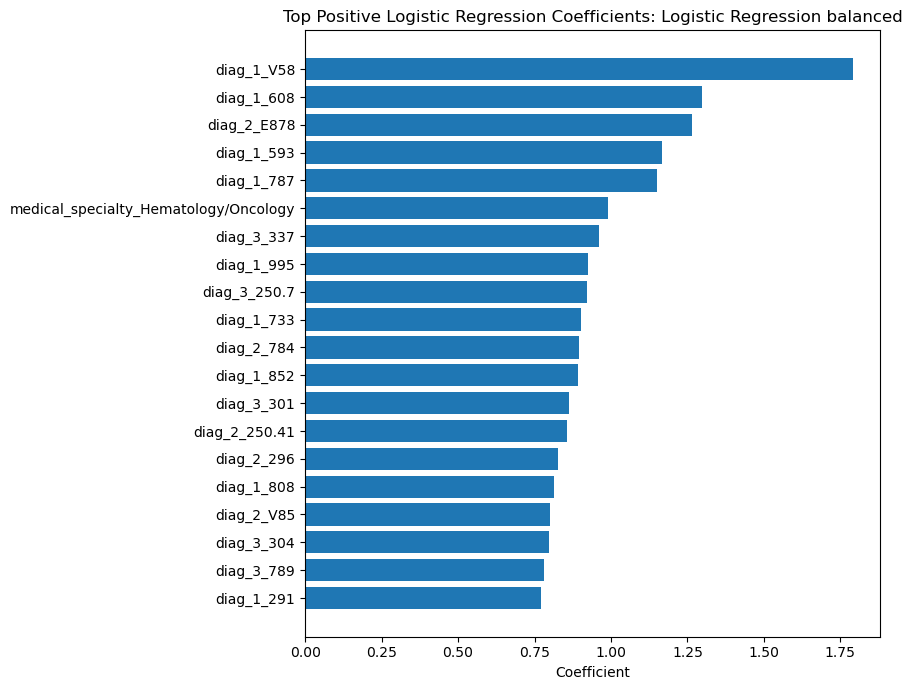

In [122]:
if len(logistic_model_names) > 0:
    plt.figure(figsize=(9, 7))

    plot_df = top_positive.sort_values("coefficient")

    plt.barh(
        plot_df["feature"],
        plot_df["coefficient"]
    )

    plt.title(f"Top Positive Logistic Regression Coefficients: {logistic_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

In [123]:
RUN_PERMUTATION_IMPORTANCE = True
PERMUTATION_SAMPLE_SIZE = 3000 if FAST_MODE else 5000

if RUN_PERMUTATION_IMPORTANCE:
    X_perm = X_val.sample(
        min(len(X_val), PERMUTATION_SAMPLE_SIZE),
        random_state=RANDOM_STATE
    )

    y_perm = y_val.loc[X_perm.index]

    print(f"Running permutation importance on {len(X_perm)} validation rows...")

    permutation_result = permutation_importance(
        best_model,
        X_perm,
        y_perm,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        "feature": X_perm.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std
    })

    perm_df = perm_df.sort_values(
        "importance_mean",
        ascending=False
    )

    display(perm_df.head(25))

else:
    print("Permutation importance skipped.")

Running permutation importance on 3000 validation rows...


,feature,importance_mean,importance_std
15,number_inpatient,0.054132,0.006722
5,discharge_disposition_id,0.017644,0.004432
21,A1Cresult,0.005208,0.002483
18,diag_3,0.004026,0.003632
14,number_emergency,0.003351,0.002273
22,metformin,0.002236,0.001384
12,num_medications,0.001283,0.001643
11,num_procedures,0.000819,0.000924
52,num_med_steady,0.000744,0.000535
10,num_lab_procedures,0.000710,0.001192


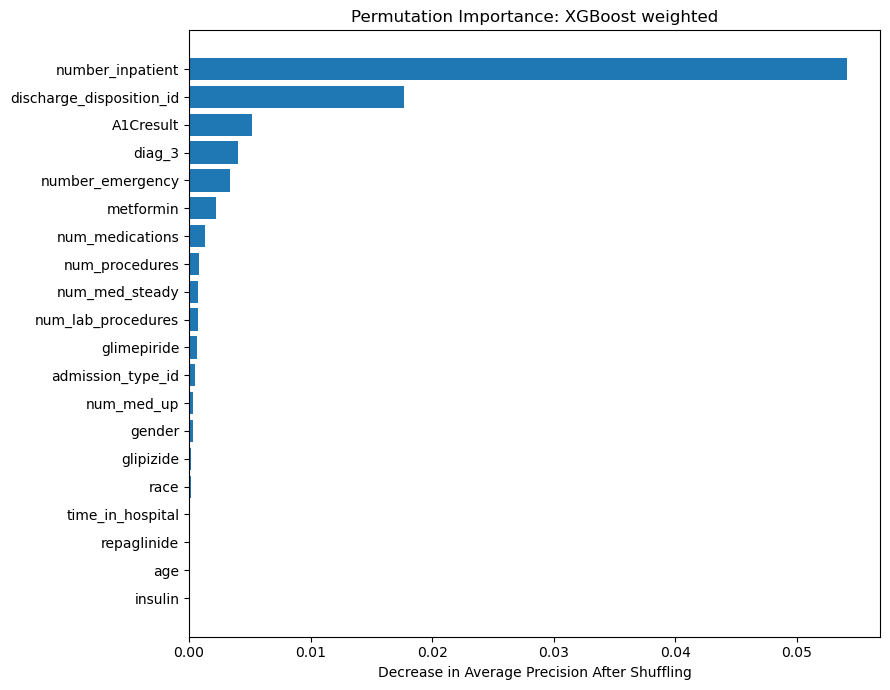

In [124]:
if RUN_PERMUTATION_IMPORTANCE:
    plt.figure(figsize=(9, 7))

    plot_df = perm_df.head(20).sort_values("importance_mean")

    plt.barh(
        plot_df["feature"],
        plot_df["importance_mean"]
    )

    plt.xlabel("Decrease in Average Precision After Shuffling")
    plt.title(f"Permutation Importance: {best_model_name}")
    plt.tight_layout()
    plt.show()